# Modeling: Predicting Social Media Addiction Score

**Approach:**
- Regression: Predict `Addicted_Score` (2-9) as continuous
- Multiple models: Linear Regression, Random Forest, XGBoost, Gradient Boosting
- Evaluation: RMSE, MAE, R², visualizations

In [1]:
# Setup
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Install with: pip install xgboost")

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 110

# Load data
FILENAME = "Students Social Media Addiction.csv"
KAGGLE_PATH = "/kaggle/input/student-social-media-addiction-analysis-dataset/Students Social Media Addiction.csv"

candidate_paths = [
    os.path.join("..", "Dataset", FILENAME),
    os.path.join("Dataset", FILENAME),
    KAGGLE_PATH,
]

found_path = None
for p in candidate_paths:
    if os.path.exists(p):
        found_path = p
        break

if found_path is None and os.path.exists("/kaggle/input"):
    matches = list(Path("/kaggle/input").rglob(FILENAME))
    if matches:
        found_path = str(matches[0])

if found_path is None:
    raise FileNotFoundError(f"Could not find {FILENAME}")

print("Loading:", found_path)
df = pd.read_csv(found_path)
print(f"Shape: {df.shape}")

Loading: /kaggle/input/student-social-media-addiction-analysis-dataset/Students Social Media Addiction.csv
Shape: (705, 13)


## Part 1: Feature Engineering

Create derived features based on EDA insights.

In [2]:
# Create a working copy
df_fe = df.copy()

# 1. Age groups
def age_group(age):
    if age <= 19:
        return "Teen"
    elif age <= 22:
        return "Young_Adult"
    else:
        return "Adult"

df_fe["Age_Group"] = df_fe["Age"].apply(age_group)

# 2. Usage intensity
def usage_intensity(hours):
    if hours < 3:
        return "Light"
    elif hours <= 6:
        return "Moderate"
    else:
        return "Heavy"

df_fe["Usage_Intensity"] = df_fe["Avg_Daily_Usage_Hours"].apply(usage_intensity)

# 3. Sleep quality
def sleep_quality(hours):
    if hours < 6:
        return "Poor"
    elif hours <= 8:
        return "Adequate"
    else:
        return "Good"

df_fe["Sleep_Quality"] = df_fe["Sleep_Hours_Per_Night"].apply(sleep_quality)

# 4. Mental health categories
def mental_health_cat(score):
    if score <= 5:
        return "Low"
    elif score <= 7:
        return "Medium"
    else:
        return "High"

df_fe["Mental_Health_Category"] = df_fe["Mental_Health_Score"].apply(mental_health_cat)

# 5. Interaction features
df_fe["Usage_x_Sleep"] = df_fe["Avg_Daily_Usage_Hours"] * df_fe["Sleep_Hours_Per_Night"]
df_fe["Usage_x_MentalHealth"] = df_fe["Avg_Daily_Usage_Hours"] * df_fe["Mental_Health_Score"]
df_fe["Conflicts_x_Usage"] = df_fe["Conflicts_Over_Social_Media"] * df_fe["Avg_Daily_Usage_Hours"]
df_fe["Sleep_x_MentalHealth"] = df_fe["Sleep_Hours_Per_Night"] * df_fe["Mental_Health_Score"]

# 6. Ratio features
df_fe["Usage_Sleep_Ratio"] = df_fe["Avg_Daily_Usage_Hours"] / (df_fe["Sleep_Hours_Per_Night"] + 0.1)
df_fe["Conflicts_Usage_Ratio"] = df_fe["Conflicts_Over_Social_Media"] / (df_fe["Avg_Daily_Usage_Hours"] + 0.1)

print("Feature engineering complete!")
print(f"  Original features: {df.shape[1]}")
print(f"  New features: {df_fe.shape[1]}")
print(f"  Added: {df_fe.shape[1] - df.shape[1]} features")

Feature engineering complete!
  Original features: 13
  New features: 23
  Added: 10 features


## Part 2: Handle High-Cardinality Categorical (Country)

In [3]:
# Top-N encoding: keep top 15 countries, group rest as "Other"
TOP_N_COUNTRIES = 15
country_counts = df_fe["Country"].value_counts()
top_countries = set(country_counts.head(TOP_N_COUNTRIES).index)

df_fe["Country_Grouped"] = df_fe["Country"].apply(
    lambda x: x if x in top_countries else "Other"
)

print(f"Country grouping: {TOP_N_COUNTRIES} top countries + 'Other'")
print(f"Unique countries after grouping: {df_fe['Country_Grouped'].nunique()}")

Country grouping: 15 top countries + 'Other'
Unique countries after grouping: 16


## Part 3: Prepare Features & Split Data

In [4]:
# Define target
target = "Addicted_Score"
y = df_fe[target].copy()

# Drop columns we don't want as features
drop_cols = [
    "Student_ID",
    "Country",  # Using Country_Grouped instead
    target,
]

# Select feature columns
feature_cols = [c for c in df_fe.columns if c not in drop_cols]
X = df_fe[feature_cols].copy()

print(f"Features: {len(feature_cols)}")
print(f"Target: {target}")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Features: 21
Target: Addicted_Score

Train set: 564 samples
Test set: 141 samples


## Part 4: Encode Categorical Features

In [5]:
# Identify categorical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numeric columns: {len(num_cols)}")

# One-hot encode categoricals
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Ensure test has same columns as train
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0

# Reorder columns to match train
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print(f"\nAfter encoding:")
print(f"  Train shape: {X_train_encoded.shape}")
print(f"  Test shape: {X_test_encoded.shape}")
print(f"  Total features: {X_train_encoded.shape[1]}")

Categorical columns: 10
Numeric columns: 11

After encoding:
  Train shape: (564, 61)
  Test shape: (141, 61)
  Total features: 61


## Part 5: Scale Numeric Features

In [6]:
# Identify numeric columns to scale (exclude one-hot encoded)
numeric_cols_after_encoding = X_train_encoded.select_dtypes(include=[np.number]).columns.tolist()
one_hot_cols = [c for c in X_train_encoded.columns if any(cat in c for cat in cat_cols)]
numeric_to_scale = [c for c in numeric_cols_after_encoding if c not in one_hot_cols]

print(f"Numeric columns to scale: {len(numeric_to_scale)}")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train_encoded[numeric_to_scale])
X_test_scaled[numeric_to_scale] = scaler.transform(X_test_encoded[numeric_to_scale])

print("Scaling complete!")

Numeric columns to scale: 11
Scaling complete!


## Part 6: Train Multiple Models

We'll train and compare:
1. Linear Regression (baseline)
2. Ridge Regression (L2 regularization)
3. Lasso Regression (L1 regularization)
4. Random Forest
5. Gradient Boosting
6. XGBoost (if available)

In [7]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train and evaluate models
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        "Model": name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train R²": train_r2,
        "Test R²": test_r2,
    })
    
    print(f"  Test RMSE: {test_rmse:.3f}")
    print(f"  Test MAE: {test_mae:.3f}")
    print(f"  Test R²: {test_r2:.3f}")

# Results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
display(results_df.round(4))


Training Linear Regression...
  Test RMSE: 0.251
  Test MAE: 0.192
  Test R²: 0.975

Training Ridge...
  Test RMSE: 0.248
  Test MAE: 0.192
  Test R²: 0.975

Training Lasso...
  Test RMSE: 0.368
  Test MAE: 0.298
  Test R²: 0.946

Training Random Forest...
  Test RMSE: 0.182
  Test MAE: 0.065
  Test R²: 0.987

Training Gradient Boosting...
  Test RMSE: 0.213
  Test MAE: 0.115
  Test R²: 0.982

Training XGBoost...
  Test RMSE: 0.188
  Test MAE: 0.059
  Test R²: 0.986

MODEL COMPARISON


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²
0,Linear Regression,0.2415,0.2510,0.1677,0.1917,0.9768,0.9748
1,Ridge,0.2438,0.2485,0.1715,0.1919,0.9764,0.9753
2,Lasso,0.3838,0.3682,0.3041,0.2980,0.9415,0.9458
3,Random Forest,0.0723,0.1821,0.0252,0.0645,0.9979,0.9867
4,Gradient Boosting,0.1158,0.2129,0.0648,0.1153,0.9947,0.9819
5,XGBoost,0.0015,0.1885,0.0010,0.0593,1.0000,0.9858


## Part 7: Visualize Model Performance

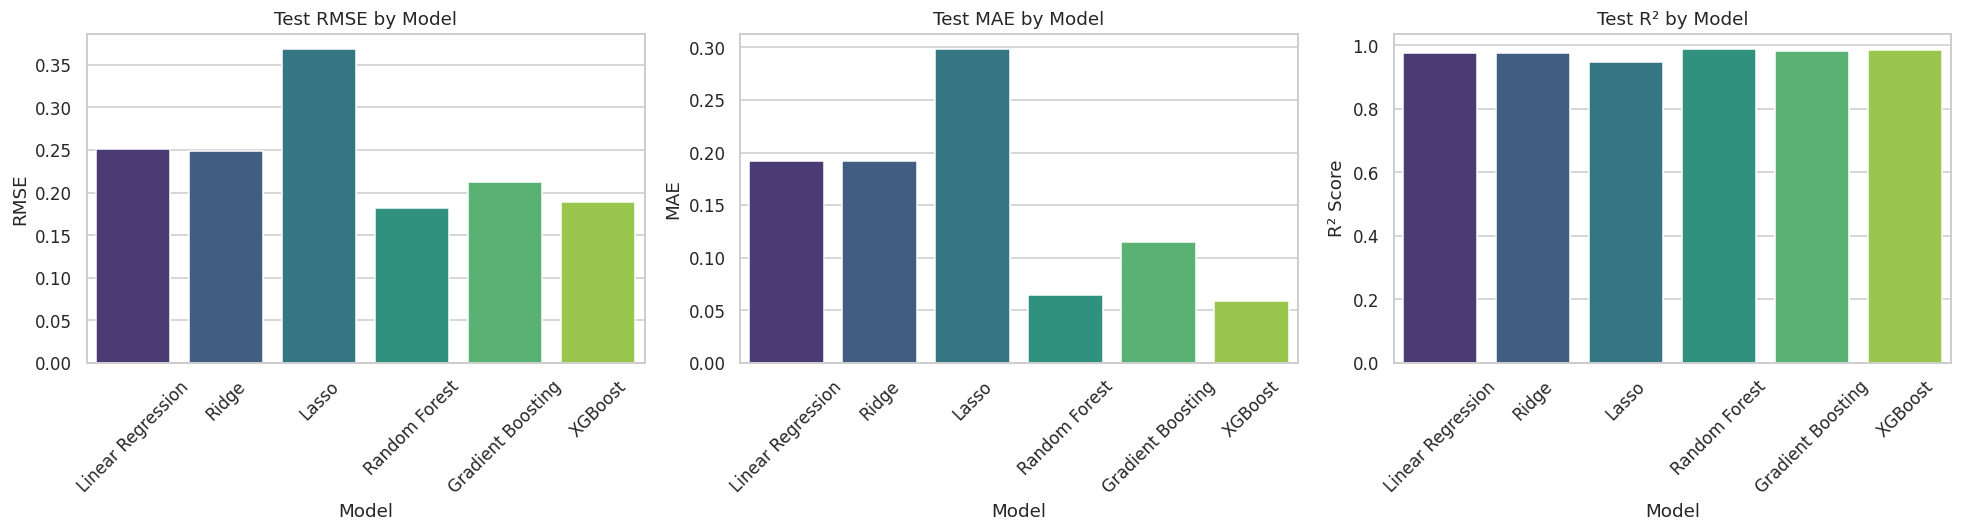


Best model (lowest Test RMSE): Random Forest
  Test RMSE: 0.1821
  Test R²: 0.9867


In [8]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
sns.barplot(data=results_df, x="Model", y="Test RMSE", ax=axes[0], palette="viridis")
axes[0].set_title("Test RMSE by Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

# MAE comparison
sns.barplot(data=results_df, x="Model", y="Test MAE", ax=axes[1], palette="viridis")
axes[1].set_title("Test MAE by Model")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

# R² comparison
sns.barplot(data=results_df, x="Model", y="Test R²", ax=axes[2], palette="viridis")
axes[2].set_title("Test R² by Model")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Find best model
best_model_name = results_df.loc[results_df["Test RMSE"].idxmin(), "Model"]
print(f"\nBest model (lowest Test RMSE): {best_model_name}")
print(f"  Test RMSE: {results_df.loc[results_df['Test RMSE'].idxmin(), 'Test RMSE']:.4f}")
print(f"  Test R²: {results_df.loc[results_df['Test RMSE'].idxmin(), 'Test R²']:.4f}")

## Part 8: Predictions vs Actual (Best Model)

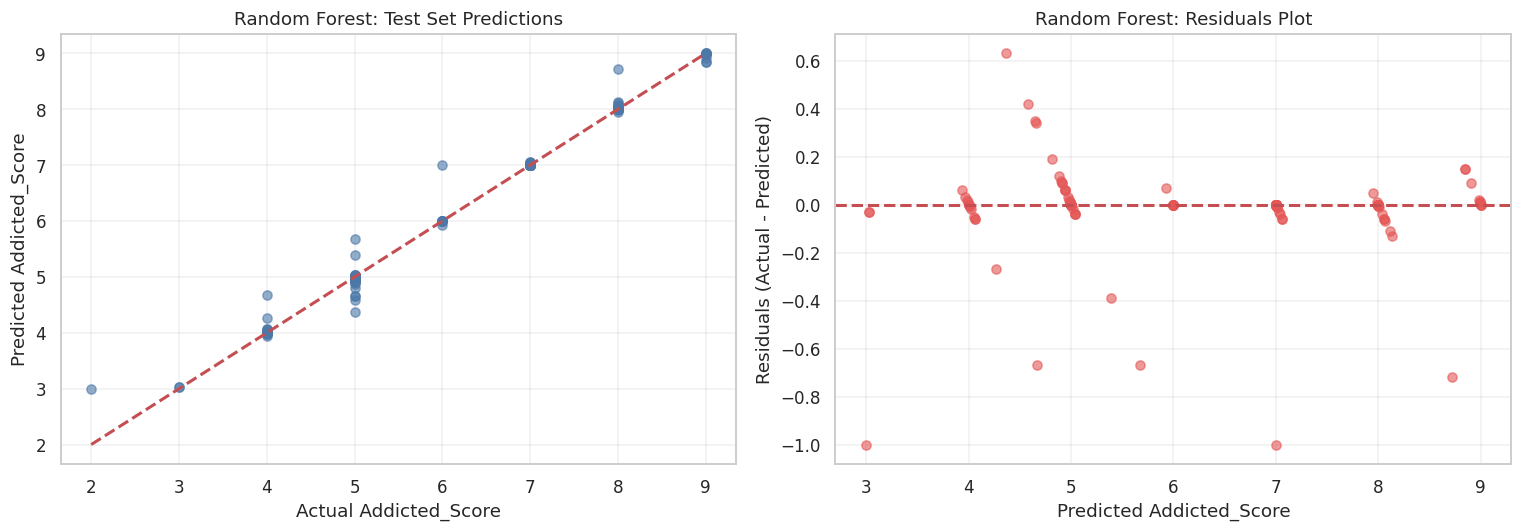

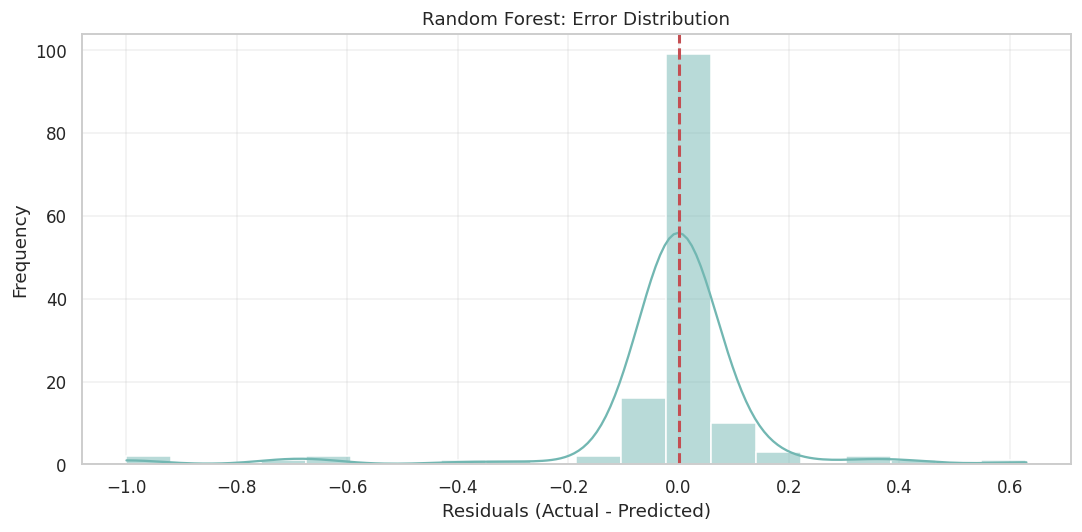

In [9]:
# Get best model predictions
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_test_pred_best = best_model.predict(X_test_scaled)

# Scatter plot: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test set
axes[0].scatter(y_test, y_test_pred_best, alpha=0.6, color="#4C78A8")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Addicted_Score")
axes[0].set_ylabel("Predicted Addicted_Score")
axes[0].set_title(f"{best_model_name}: Test Set Predictions")
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred_best
axes[1].scatter(y_test_pred_best, residuals, alpha=0.6, color="#E45756")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Addicted_Score")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title(f"{best_model_name}: Residuals Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=20, kde=True, color="#72B7B2")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title(f"{best_model_name}: Error Distribution")
plt.axvline(x=0, color="r", linestyle="--", lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 9: Feature Importance (Best Model)

If the best model supports feature importance, visualize it.

Top 20 Most Important Features (Random Forest):


,feature,importance
3,Mental_Health_Score,0.787864
4,Conflicts_Over_Social_Media,0.099397
42,Mental_Health_Category_High,0.021145
44,Mental_Health_Category_Medium,0.020672
8,Sleep_x_MentalHealth,0.018697
7,Conflicts_x_Usage,0.010199
18,Most_Used_Platform_KakaoTalk,0.006818
19,Most_Used_Platform_LINE,0.005650
5,Usage_x_Sleep,0.004627
49,Country_Grouped_India,0.003232


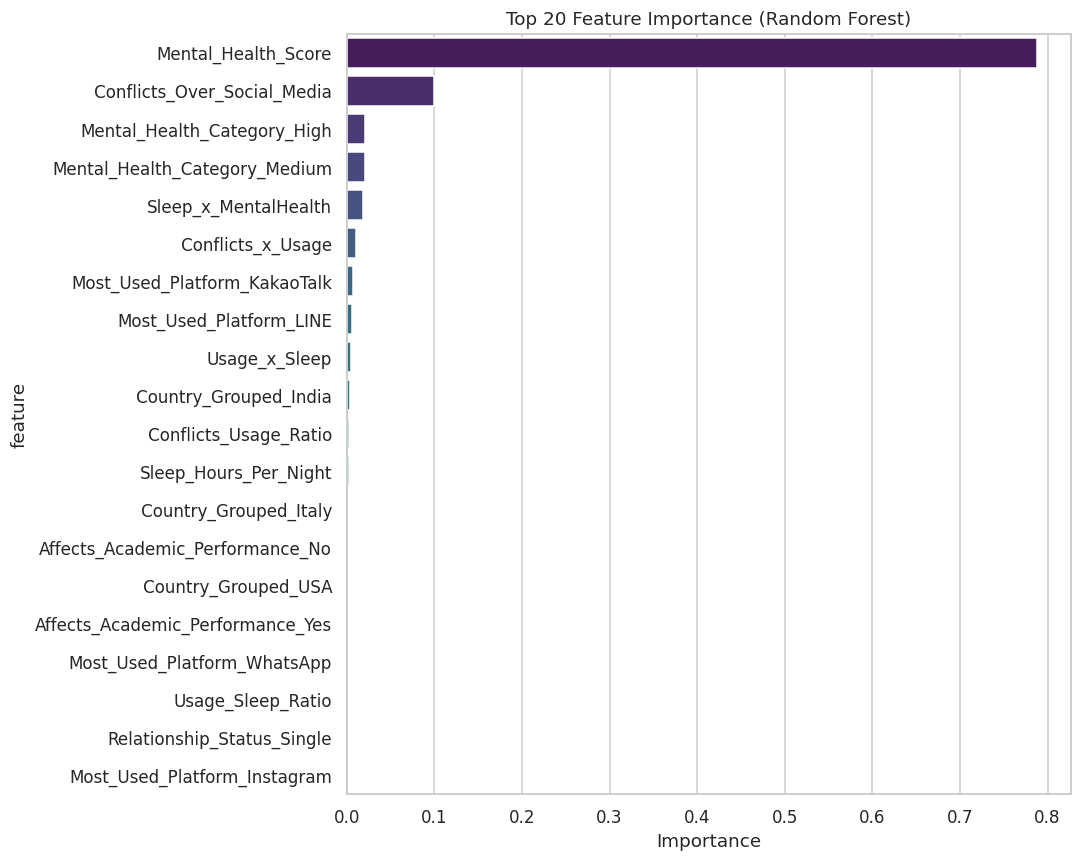

In [10]:
# Feature importance for tree-based models
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": X_train_scaled.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)
    
    print(f"Top 20 Most Important Features ({best_model_name}):")
    display(feature_importance.head(20))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    sns.barplot(data=top_features, y="feature", x="importance", palette="viridis")
    plt.title(f"Top 20 Feature Importance ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, "coef_"):
    # For linear models, show coefficients
    feature_importance = pd.DataFrame({
        "feature": X_train_scaled.columns,
        "coefficient": best_model.coef_
    }).sort_values("coefficient", key=abs, ascending=False)
    
    print(f"Top 20 Largest Coefficients ({best_model_name}):")
    display(feature_importance.head(20))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    sns.barplot(data=top_features, y="feature", x="coefficient", palette="coolwarm")
    plt.title(f"Top 20 Coefficients ({best_model_name})")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support feature importance visualization.")